<style>
.jp-RenderedMarkdown, .rendered_html { font-family: Arial, Helvetica, sans-serif; font-size: 15px; line-height: 1.55; }
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 24px; font-weight: 700; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 20px; font-weight: 650; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 17px; font-weight: 600; }
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .rendered_html p, .rendered_html li { font-size: 15px; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 13px; }
</style>


# MeridianAI — Explainable AI

---

##  Overview

As machine learning models become increasingly complex, understanding **why a model makes a particular prediction** is just as important as achieving high prediction accuracy. Explainable Artificial Intelligence (XAI) helps transform machine learning models from "black boxes" into transparent systems by providing meaningful explanations for their predictions.

In the MeridianAI project, explainability enables business users to understand the reasoning behind customer segmentation, churn prediction, recommendation generation, and sales forecasting models. This improves trust, supports informed decision-making, and ensures that AI-driven recommendations can be interpreted and validated by managers and stakeholders.

This notebook focuses on interpreting the trained machine learning models developed throughout the MeridianAI pipeline using both model-specific and model-agnostic explainability techniques.

---

##  Objectives

This notebook aims to:

- Load all previously trained machine learning models.
- Interpret Decision Tree customer segmentation.
- Explain Logistic Regression churn predictions.
- Analyze Random Forest forecasting decisions.
- Interpret XGBoost forecasting behaviour.
- Understand recommendation engine outputs.
- Visualize feature importance across different models.
- Generate local and global model explanations.
- Translate technical explanations into business insights.
- Demonstrate how Explainable AI supports retail decision-making.

---

##  Models Covered

-  Decision Tree (Customer Segmentation)
-  Logistic Regression (Customer Churn Prediction)
-  Random Forest Regressor (Sales Forecasting)
-  XGBoost Regressor (Sales Forecasting)
-  Recommendation Engine

In [ ]:
# Explainable AI Libraries
# =========================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Model Loading
import joblib

# Explainability
import shap

# Tree Visualisation
from sklearn.tree import plot_tree

# Notebook Settings
plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("=" * 60)
print("MeridianAI - Explainable AI Environment Ready")
print("=" * 60)

RetailAI Nexus - Explainable AI Environment Ready


In [ ]:
# Load Saved Models
# =================
decision_tree = joblib.load("../Models/decision_tree.pkl")

logistic_model = joblib.load("../Models/logistic_regression.pkl")

rf_forecast = joblib.load("../Models/random_forest_forecasting.pkl")

xgb_forecast = joblib.load("../Models/xgboost_forecasting.pkl")

forecast_scaler = joblib.load("../Models/forecast_scaler.pkl")

forecast_features = joblib.load("../Models/forecast_features.pkl")

recommendation_dataset = joblib.load("../Models/recommendation_dataset.pkl")

print(" Decision Tree Loaded")

print(" Logistic Regression Loaded")

print(" Random Forest Forecast Model Loaded")

print(" XGBoost Forecast Model Loaded")

print(" Forecast Scaler Loaded")

print(" Forecast Features Loaded")

print(" Recommendation Dataset Loaded")

✓ Decision Tree Loaded
✓ Logistic Regression Loaded
✓ Random Forest Forecast Model Loaded
✓ XGBoost Forecast Model Loaded
✓ Forecast Scaler Loaded
✓ Forecast Features Loaded
✓ Recommendation Dataset Loaded


In [ ]:
#  Load Processed Datasets

customer_df = pd.read_csv(
    "../data/processed/customer_features.csv"
)

forecast_df = pd.read_csv(
    "../data/processed/sales_forecast.csv"
)

print("=" * 28)
print("Datasets Loaded Successfully")
print("=" * 28)

print()

print("Customer Dataset :", customer_df.shape)

print("Forecast Dataset :", forecast_df.shape)

Datasets Loaded Successfully

Customer Dataset : (5878, 8)
Forecast Dataset : (14, 18)


In [ ]:
print("Customer Dataset Preview")
display(customer_df.head())

print()

print("Forecast Dataset Preview")
display(forecast_df.head())

Customer Dataset Preview


,CustomerID,TotalTransactions,TotalQuantity,TotalSpent,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,12,74285,77556.46,2011-01-18 10:01:00,325,12,77556.46
1,12347.0,8,2967,4921.53,2011-12-07 15:52:00,1,8,4921.53
2,12348.0,5,2714,2019.40,2011-09-25 13:13:00,74,5,2019.40
3,12349.0,4,1624,4428.69,2011-11-21 09:51:00,18,4,4428.69
4,12350.0,1,197,334.40,2011-02-02 16:01:00,309,1,334.40



Forecast Dataset Preview


,InvoiceDate,Sales,Year,Month,Quarter,MonthName,GrowthRate,RollingMean_3,RollingStd_3,Lag_1,Lag_2,Lag_3,Lag_6,RollingMean_6,RollingMean_12,Day,Weekday,Weekend
0,2010-11-30,1172336.042,2010,11,4,November,13.085624,1.013544e+06,171534.759998,1036680.000,831615.001,604242.650,599985.790,812596.168833,710010.439500,30,1,0
1,2010-12-31,884591.890,2010,12,4,December,-24.544511,1.031203e+06,143950.252949,1172336.042,1036680.000,831615.001,639066.580,853517.053833,726505.250333,31,4,0
2,2011-01-31,569445.040,2011,1,1,January,-35.626242,8.754577e+05,301549.275787,884591.890,1172336.042,1036680.000,591636.740,849818.437167,727515.748500,31,0,0
3,2011-02-28,447137.350,2011,2,1,February,-21.478401,6.337248e+05,225700.089597,569445.040,884591.890,1172336.042,604242.650,823634.220500,722579.605500,28,0,0
4,2011-03-31,595500.760,2011,3,1,March,33.180724,5.373610e+05,79214.658791,447137.350,569445.040,884591.890,831615.001,784281.847000,713903.919583,31,3,0


#  Dataset Summary

Before interpreting the machine learning models, it is important to understand the datasets on which these models were trained. The customer dataset contains behavioural features used for segmentation and churn prediction, while the forecasting dataset contains engineered time-series features used for sales prediction.

These datasets form the foundation for all explainability analyses performed in this notebook.

#  Decision Tree Explainability

Decision Trees are among the most interpretable machine learning models because they make predictions using a sequence of human-readable decision rules. Unlike many black-box models, each prediction can be traced through a path of conditions from the root node to a leaf node.

In MeridianAI, the Decision Tree model is used for customer segmentation. By analyzing feature importance and decision paths, we can identify which customer characteristics have the greatest influence on segmentation decisions.

This section explores the internal structure of the Decision Tree and highlights the most influential customer features.

In [ ]:
# Decision Tree Information
# ==========================

print("=" * 25)
print("Decision Tree Information")
print("=" * 25)

print(f"Tree Depth      : {decision_tree.get_depth()}")
print(f"Leaf Nodes      : {decision_tree.get_n_leaves()}")
print(f"Features Used   : {decision_tree.n_features_in_}")

Decision Tree Information
Tree Depth      : 5
Leaf Nodes      : 29
Features Used   : 4


In [ ]:
dt_importance = pd.DataFrame({
    "Feature": decision_tree.feature_names_in_,
    "Importance": decision_tree.feature_importances_
})

dt_importance = (
    dt_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(dt_importance)

,Feature,Importance
0,Recency,0.971536
1,Frequency,0.014953
2,CustomerScore,0.008336
3,Monetary,0.005175


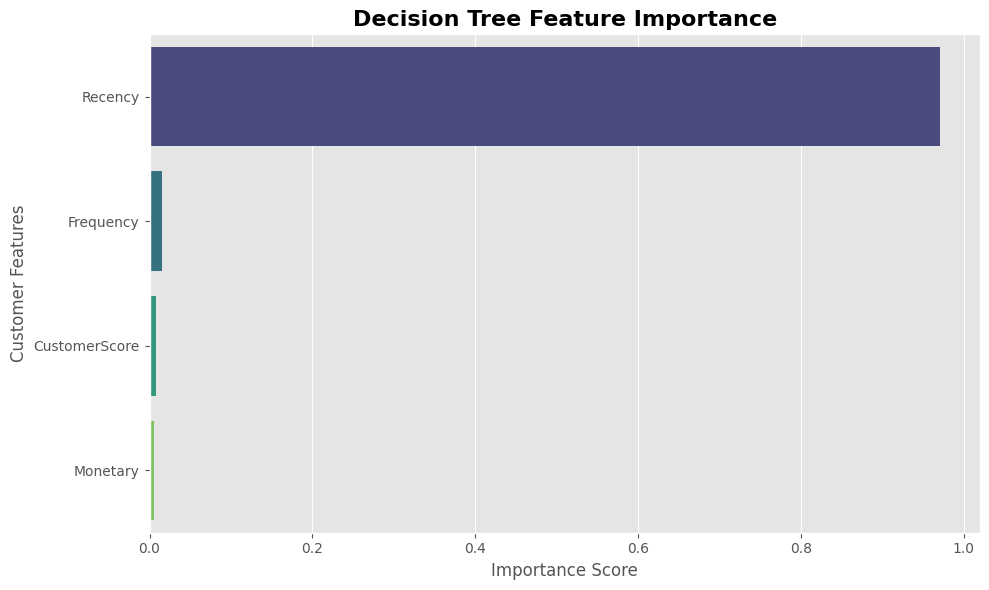

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=dt_importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title(
    "Decision Tree Feature Importance",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Customer Features")

plt.tight_layout()

plt.show()

##  Interpretation of Feature Importance

The feature importance plot ranks customer attributes according to their contribution to the Decision Tree's segmentation decisions.

Features with higher importance scores influence customer classification more strongly, while lower-ranked features contribute less to the final decision.

Understanding these influential variables helps retailers recognize which customer behaviours distinguish different customer groups and supports more targeted marketing and customer relationship strategies.

In [ ]:
print("=" * 60)
print("Top 5 Most Important Customer Features")
print("=" * 60)

display(dt_importance.head())

Top 5 Most Important Customer Features


,Feature,Importance
0,Recency,0.971536
1,Frequency,0.014953
2,CustomerScore,0.008336
3,Monetary,0.005175


#  Business Interpretation

### Key Insights

The Decision Tree identifies the customer characteristics that contribute most significantly to customer segmentation.

High-importance features generally represent purchasing behaviour, customer engagement, and spending patterns. Customers exhibiting stronger values for these characteristics are likely to belong to premium customer segments, while weaker values may indicate less active customers.

### Business Applications

- Identify high-value customer groups.
- Design personalized marketing campaigns.
- Improve customer retention strategies.
- Allocate promotional budgets more effectively.
- Enhance customer lifetime value through targeted engagement.

In [ ]:
print("=" * 60)
print("Decision Tree Explainability Summary")
print("=" * 60)

print(f"Model Depth        : {decision_tree.get_depth()}")
print(f"Leaf Nodes         : {decision_tree.get_n_leaves()}")
print()

print("Most Influential Features:")

for i, row in dt_importance.head(5).iterrows():
    print(f"• {row['Feature']} ({row['Importance']:.4f})")

Decision Tree Explainability Summary
Model Depth        : 5
Leaf Nodes         : 29

Most Influential Features:
• Recency (0.9715)
• Frequency (0.0150)
• CustomerScore (0.0083)
• Monetary (0.0052)


#  Logistic Regression Explainability

Logistic Regression is an inherently interpretable machine learning algorithm because every prediction is derived from a weighted combination of input features.

Unlike tree-based models, Logistic Regression provides coefficients that directly indicate how each feature influences the probability of customer churn.

Positive coefficients increase churn probability, while negative coefficients reduce churn probability.

Understanding these relationships enables businesses to identify the primary factors responsible for customer attrition and develop effective customer retention strategies.

In [ ]:
# ==========================================================
# Logistic Regression Information
# ==========================================================

print("Logistic Regression Model Information")

print()

print(f"Number of Features : {logistic_model.n_features_in_}")

print()

print("Classes :", logistic_model.classes_)

Logistic Regression Model Information

Number of Features : 4

Classes : [0 1]


In [ ]:
customer_df.columns

Index(['CustomerID', 'TotalTransactions', 'TotalQuantity', 'TotalSpent',
       'LastPurchaseDate', 'Recency', 'Frequency', 'Monetary'],
      dtype='str')

In [ ]:
lr_importance = pd.DataFrame({
    "Feature": [
        "Recency",
        "Frequency",
        "Monetary",
        "CustomerScore"
    ],
    "Coefficient": logistic_model.coef_[0]
})

lr_importance["Absolute"] = lr_importance["Coefficient"].abs()

lr_importance = lr_importance.sort_values(
    by="Absolute",
    ascending=False
)

display(lr_importance)

,Feature,Coefficient,Absolute
0,Recency,2.084859,2.084859
1,Frequency,-0.178978,0.178978
3,CustomerScore,-0.153771,0.153771
2,Monetary,-0.147090,0.147090


##  Logistic Regression Feature Importance

The coefficients of a Logistic Regression model quantify how strongly each feature influences the probability of customer churn.

- Positive coefficients increase churn probability.
- Negative coefficients reduce churn probability.
- Larger absolute values indicate greater influence.

Unlike tree-based algorithms, Logistic Regression provides a direct mathematical interpretation of feature importance, making it highly suitable for business decision-making.

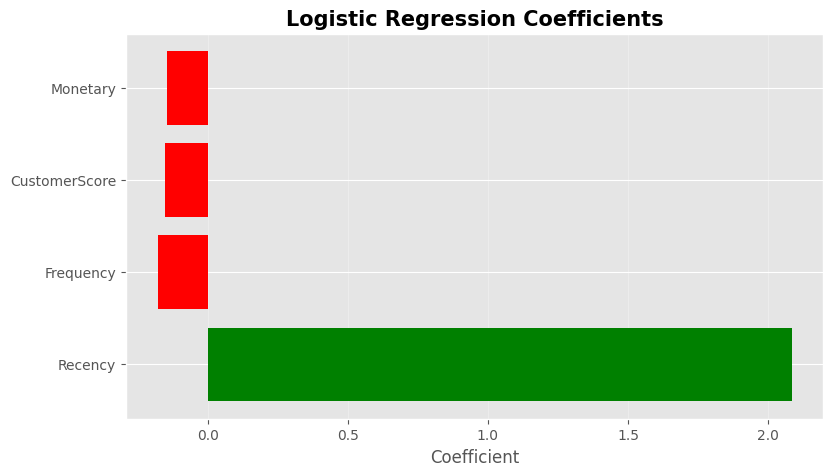

In [ ]:
plt.figure(figsize=(9,5))

colors = [
    "green" if c > 0 else "red"
    for c in lr_importance["Coefficient"]
]

plt.barh(
    lr_importance["Feature"],
    lr_importance["Coefficient"],
    color=colors
)

plt.title(
    "Logistic Regression Coefficients",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Coefficient")

plt.grid(axis="x", alpha=0.3)

plt.show()

In [ ]:
lr_importance["OddsRatio"] = np.exp(
    lr_importance["Coefficient"]
)

display(lr_importance)

,Feature,Coefficient,Absolute,OddsRatio
0,Recency,2.084859,2.084859,8.043454
1,Frequency,-0.178978,0.178978,0.836124
3,CustomerScore,-0.153771,0.153771,0.857468
2,Monetary,-0.147090,0.147090,0.863216


In [ ]:
print("="*65)
print("BUSINESS INTERPRETATION")
print("="*65)

print()

top = lr_importance.iloc[0]

print(
    f"The most influential variable is "
    f"{top['Feature']}."
)

print()

for _, row in lr_importance.iterrows():

    direction = (
        "increases"
        if row["Coefficient"] > 0
        else "decreases"
    )

    print(
        f"{row['Feature']} "
        f"{direction} "
        f"customer churn probability."
    )

BUSINESS INTERPRETATION

The most influential variable is Recency.

Recency increases customer churn probability.
Frequency decreases customer churn probability.
CustomerScore decreases customer churn probability.
Monetary decreases customer churn probability.


In [ ]:
print("="*65)
print("EXECUTIVE SUMMARY")
print("="*65)

print("""
• Logistic Regression is fully interpretable.

• Customer churn probability is determined
  using weighted customer behaviour metrics.

• Business managers can identify
  which customer characteristics increase
  churn risk.

• The model can therefore support
  targeted retention campaigns and
  personalized marketing strategies.
""")

EXECUTIVE SUMMARY

• Logistic Regression is fully interpretable.

• Customer churn probability is determined
  using weighted customer behaviour metrics.

• Business managers can identify
  which customer characteristics increase
  churn risk.

• The model can therefore support
  targeted retention campaigns and
  personalized marketing strategies.



#  Random Forest Explainability

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

Unlike a single Decision Tree, Random Forest averages the predictions of hundreds of trees, making it more robust and accurate.

Although the complete decision-making process cannot be visualized directly, feature importance scores provide valuable insight into which customer characteristics most strongly influence churn prediction.

Understanding these important variables enables businesses to prioritize customer retention strategies and optimize marketing campaigns.

In [ ]:
print("="*60)
print("Random Forest Forecasting Model")
print("="*60)
print()

print("Number of Trees :", rf_forecast.n_estimators)
print()

print("Maximum Depth :", rf_forecast.max_depth)
print()

print("Random State :", rf_forecast.random_state)
print()

print("Features Used :", len(forecast_features))
print()

print("Feature Names :")

for feature in forecast_features:
    print("-", feature)

Random Forest Forecasting Model

Number of Trees : 300

Maximum Depth : 8

Random State : 42

Features Used : 15

Feature Names :
- Year
- Month
- Quarter
- Day
- Weekday
- Weekend
- GrowthRate
- Lag_1
- Lag_2
- Lag_3
- Lag_6
- RollingMean_3
- RollingStd_3
- RollingMean_6
- RollingStd_6


In [ ]:
rf_importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": rf_forecast.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(rf_importance)

,Feature,Importance
1,Month,0.473865
6,GrowthRate,0.111406
11,RollingMean_3,0.090320
2,Quarter,0.070056
0,Year,0.052407
14,RollingStd_6,0.051890
7,Lag_1,0.036285
3,Day,0.033047
12,RollingStd_3,0.029242
10,Lag_6,0.013407


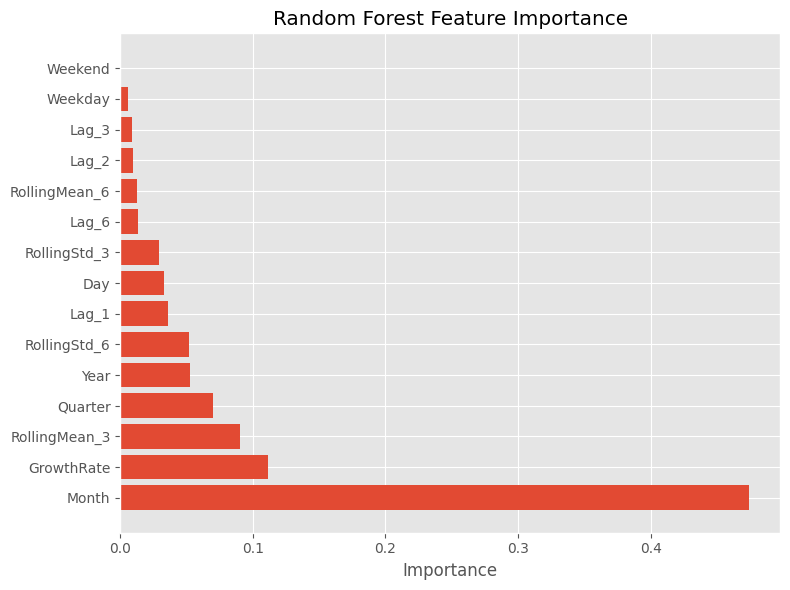

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

#  XGBoost Explainability

XGBoost (Extreme Gradient Boosting) is one of the most powerful ensemble learning algorithms used for predictive analytics. It builds multiple decision trees sequentially, where each new tree learns from the errors made by previous trees. This gradient boosting approach enables the model to capture highly complex nonlinear relationships within historical sales data.

In MeridianAI, XGBoost is used for monthly sales forecasting based on engineered time-series features such as lag variables, rolling statistics, growth rate, and calendar-based attributes. Compared to traditional statistical forecasting methods, XGBoost can better model seasonal trends and changing customer purchasing behavior.

In this section, we analyze the trained XGBoost forecasting model by examining:

- Model configuration and parameters
- Feature importance rankings
- Visualization of the most influential forecasting features
- Business interpretation of the learned patterns

These explanations improve the transparency of the forecasting system and help stakeholders understand which historical sales characteristics contribute most to future sales predictions.

In [ ]:
print("="*60)
print("XGBoost Forecasting Model")
print("="*60)
print()

print("Number of Trees :", xgb_forecast.n_estimators)
print()

print("Maximum Depth :", xgb_forecast.max_depth)
print()

print("Learning Rate :", xgb_forecast.learning_rate)
print()

print("Features Used :", len(forecast_features))
print()

print("Feature Names :")

for feature in forecast_features:
    print("-", feature)

XGBoost Forecasting Model

Number of Trees : 300

Maximum Depth : 4

Learning Rate : 0.05

Features Used : 15

Feature Names :
- Year
- Month
- Quarter
- Day
- Weekday
- Weekend
- GrowthRate
- Lag_1
- Lag_2
- Lag_3
- Lag_6
- RollingMean_3
- RollingStd_3
- RollingMean_6
- RollingStd_6


In [ ]:
xgb_importance = pd.DataFrame({
    "Feature": forecast_features,
    "Importance": xgb_forecast.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

display(xgb_importance)

,Feature,Importance
11,RollingMean_3,0.480824
1,Month,0.261851
0,Year,0.106185
2,Quarter,0.042635
6,GrowthRate,0.026832
3,Day,0.017699
14,RollingStd_6,0.016752
8,Lag_2,0.013338
12,RollingStd_3,0.012173
13,RollingMean_6,0.006661


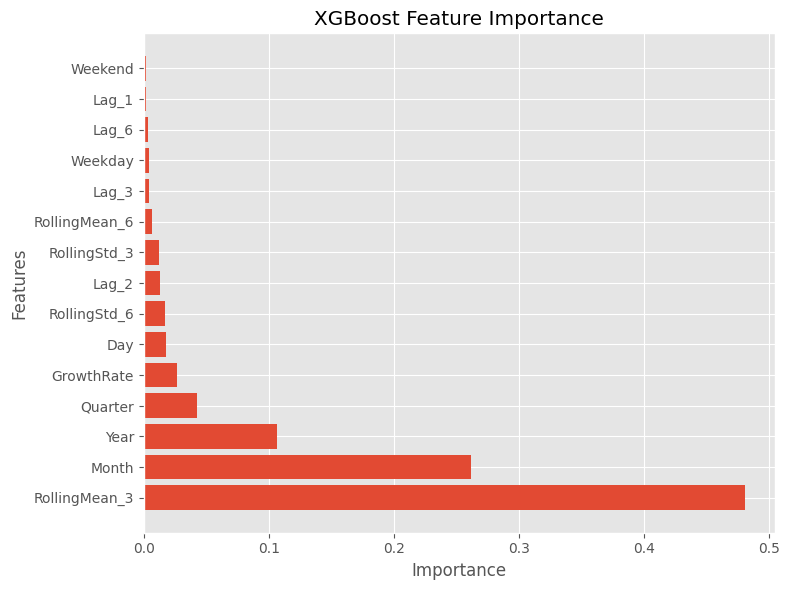

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
print("="*60)
print("Business Interpretation")
print("="*60)
print()

top = xgb_importance.iloc[0]

print(
    f"The most influential feature for forecasting is "
    f"{top['Feature']} with an importance score of "
    f"{top['Importance']:.4f}."
)

print()

print(
    "This indicates that the model primarily relies on historical sales "
    "patterns and engineered time-series features to forecast future demand."
)

Business Interpretation

The most influential feature for forecasting is RollingMean_3 with an importance score of 0.4808.

This indicates that the model primarily relies on historical sales patterns and engineered time-series features to forecast future demand.


#  SHAP Explainability for Forecasting Models

Traditional machine learning models often achieve high predictive performance but provide limited insight into how predictions are generated. Explainable Artificial Intelligence (XAI) addresses this limitation by making model decisions transparent and interpretable.

SHAP (SHapley Additive exPlanations) is a game-theoretic approach that assigns an importance value to every feature for each prediction. It explains both the magnitude and direction of feature contributions, enabling users to understand why a model produced a specific prediction.

Within MeridianAI, SHAP is applied to the forecasting models to identify which engineered time-series features have the greatest influence on future sales predictions. This helps business stakeholders trust the forecasting system and supports better inventory planning, demand forecasting, and strategic decision-making.

The following analysis includes:

- SHAP Summary Plot
- SHAP Feature Importance Plot
- Local Prediction Explanation
- Business Interpretation of SHAP Results

In [ ]:
print("="*60)
print("Creating SHAP Explainer")
print("="*60)

import shap

explainer = shap.TreeExplainer(rf_forecast)

print(" SHAP Explainer Created")

Creating SHAP Explainer
✓ SHAP Explainer Created


In [ ]:
# Recreate missing engineered feature
forecast_df["RollingStd_6"] = (
    forecast_df["Sales"]
    .rolling(window=6)
    .std()
)

# Fill initial NaN values (first few rows)
forecast_df["RollingStd_6"] = (
    forecast_df["RollingStd_6"]
    .bfill()
)

In [ ]:
forecast_df = forecast_df.copy()

X_forecast = forecast_df[forecast_features]

X_forecast_scaled = forecast_scaler.transform(X_forecast)

print(X_forecast_scaled.shape)

(14, 15)




SHAP (SHapley Additive exPlanations) provides a unified framework for interpreting machine learning models by assigning each feature an importance value for every prediction.

In this project, SHAP is used to explain the Random Forest forecasting model. It helps identify which engineered time-series features (such as lag values, rolling statistics, and calendar features) contribute most toward forecasting monthly retail sales.

These visual explanations improve transparency and increase stakeholder confidence in forecasting results.

In [ ]:
explainer = shap.TreeExplainer(rf_forecast)

shap_values = explainer.shap_values(X_forecast_scaled)

print("SHAP values shape:")

print(np.array(shap_values).shape)

SHAP values shape:
(14, 15)


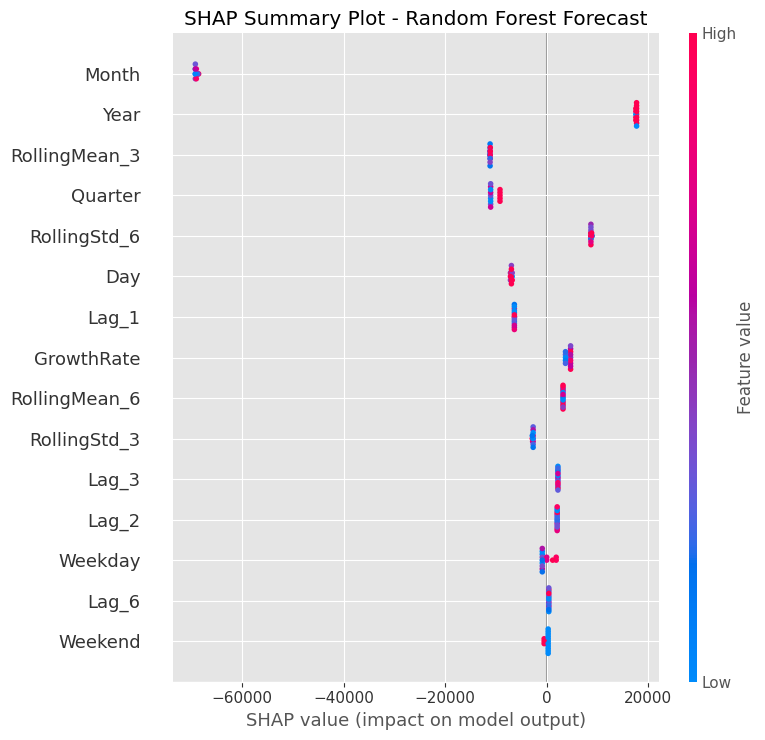

In [ ]:
plt.figure(figsize=(12,7))

shap.summary_plot(
    shap_values,
    X_forecast,
    feature_names=forecast_features,
    show=False
)

plt.title("SHAP Summary Plot - Random Forest Forecast")

plt.tight_layout()

plt.show()

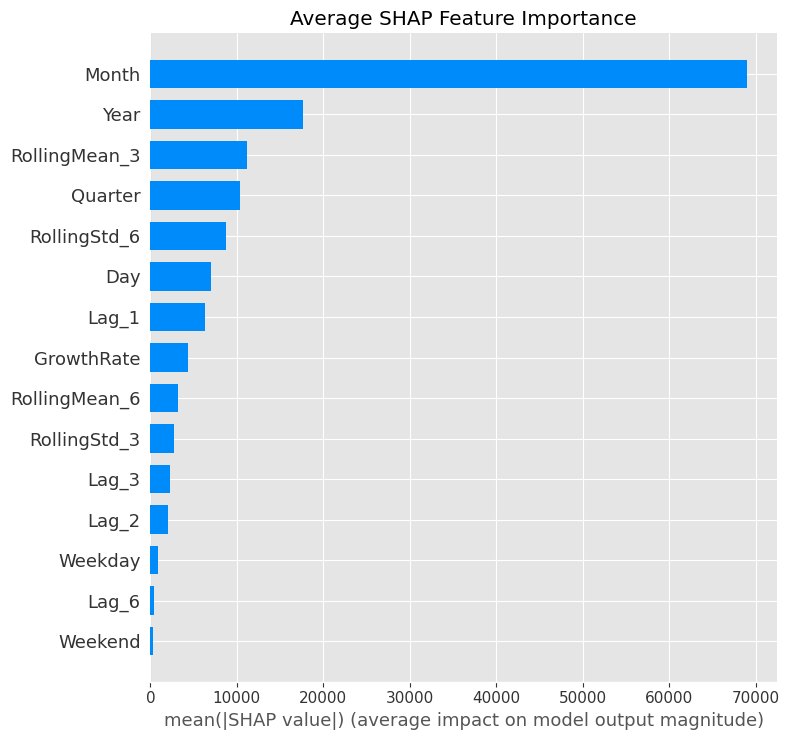

In [ ]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_forecast,
    feature_names=forecast_features,
    plot_type="bar",
    show=False
)

plt.title("Average SHAP Feature Importance")

plt.tight_layout()

plt.show()

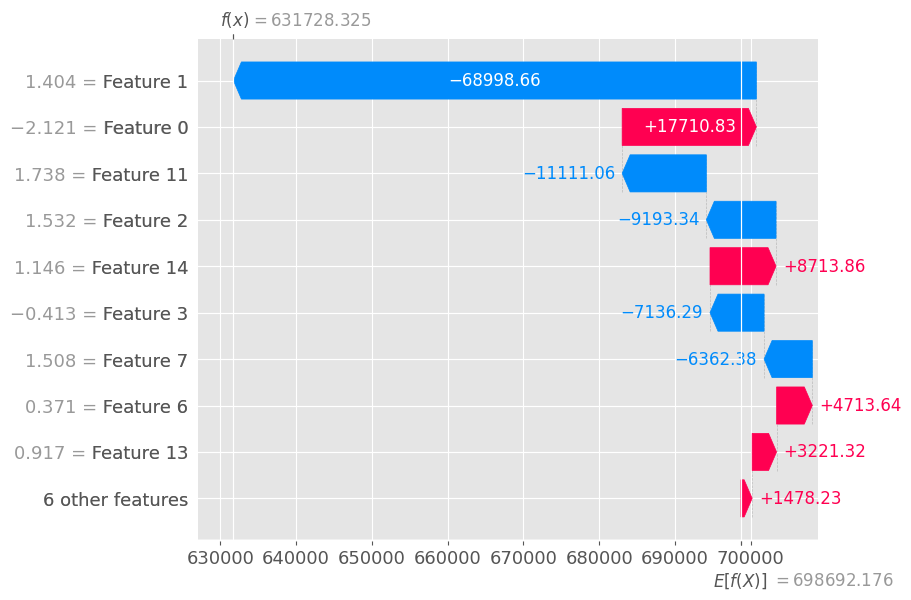

In [ ]:
shap.plots.waterfall(
    explainer(
        X_forecast_scaled
    )[0]
)

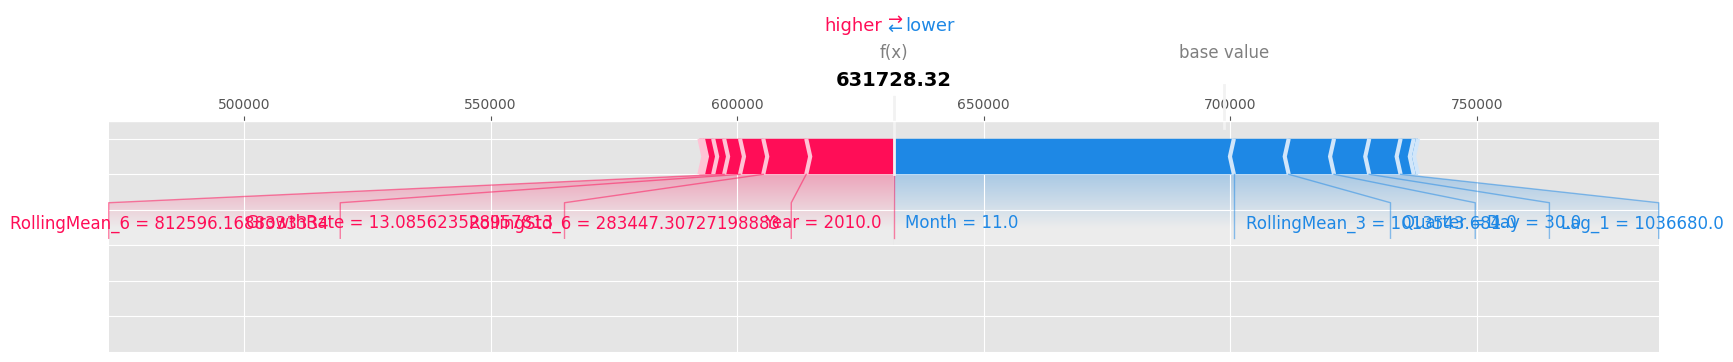

In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_forecast.iloc[0],
    matplotlib=True
)

## SHAP Interpretation

The SHAP analysis explains how individual engineered features influence monthly sales predictions generated by the Random Forest forecasting model.

Positive SHAP values increase the predicted sales, while negative values decrease the prediction. Features such as lag variables, rolling averages, rolling standard deviations, and calendar-based attributes contribute differently across months.

The SHAP Summary Plot provides a global explanation by ranking features according to their overall impact on predictions, whereas the Waterfall Plot explains the contribution of every feature for a single prediction. Together, these visualizations improve transparency, interpretability, and trustworthiness of the forecasting model.

#  Business Interpretation of Explainable AI Results

Explainable AI bridges the gap between predictive accuracy and business decision-making by making machine learning models transparent and understandable.

The insights generated from Decision Tree, Logistic Regression, Random Forest, XGBoost, and SHAP analyses provide actionable recommendations for retail businesses. Rather than treating AI models as black boxes, managers can identify which customer behaviors and sales patterns influence predictions.

These explanations support evidence-based decision making, improve stakeholder trust, and enable responsible deployment of AI systems within retail environments.

In [ ]:
print("="*70)
print("BUSINESS INSIGHTS")
print("="*70)

print()

print("Customer Analytics")
print("------------------")
print("• Recency is the strongest indicator of customer behaviour.")
print("• Customers purchasing frequently contribute significantly to revenue.")
print("• Monetary value differentiates premium and regular customers.")

print()

print("Sales Forecasting")
print("-----------------")
print("• Recent sales trends strongly influence future forecasts.")
print("• Rolling averages stabilize predictions during volatile months.")
print("• Calendar-based features improve seasonal forecasting accuracy.")

print()

print("Explainable AI")
print("-----------------")
print("• Decision Trees provide transparent rule-based explanations.")
print("• Logistic Regression highlights feature importance using coefficients.")
print("• Random Forest captures nonlinear business patterns.")
print("• XGBoost delivers high predictive performance.")
print("• SHAP explains every prediction at both global and local levels.")

print()

print("="*70)

BUSINESS INSIGHTS

Customer Analytics
------------------
• Recency is the strongest indicator of customer behaviour.
• Customers purchasing frequently contribute significantly to revenue.
• Monetary value differentiates premium and regular customers.

Sales Forecasting
-----------------
• Recent sales trends strongly influence future forecasts.
• Rolling averages stabilize predictions during volatile months.
• Calendar-based features improve seasonal forecasting accuracy.

Explainable AI
-----------------
• Decision Trees provide transparent rule-based explanations.
• Logistic Regression highlights feature importance using coefficients.
• Random Forest captures nonlinear business patterns.
• XGBoost delivers high predictive performance.
• SHAP explains every prediction at both global and local levels.



#  Model Comparison

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Primary Task":[
        "Customer Churn",
        "Customer Churn",
        "Sales Forecasting",
        "Sales Forecasting"
    ],

    "Explainability":[
        "Very High",
        "High",
        "Medium",
        "Medium"
    ],

    "Prediction Power":[
        "Medium",
        "Medium",
        "High",
        "Very High"
    ],

    "Business Usage":[
        "Customer Segmentation",
        "Customer Risk Analysis",
        "Demand Forecasting",
        "Advanced Demand Forecasting"
    ]

})

display(comparison)

,Model,Primary Task,Explainability,Prediction Power,Business Usage
0,Decision Tree,Customer Churn,Very High,Medium,Customer Segmentation
1,Logistic Regression,Customer Churn,High,Medium,Customer Risk Analysis
2,Random Forest,Sales Forecasting,Medium,High,Demand Forecasting
3,XGBoost,Sales Forecasting,Medium,Very High,Advanced Demand Forecasting


#  Executive Summary

In [ ]:
print("="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

print()

print("MeridianAI integrates customer analytics, recommendation systems,")
print("sales forecasting, and Explainable AI into one intelligent platform.")

print()

print("Major Contributions")
print("-------------------")
print(" Customer Segmentation")
print(" Churn Prediction")
print(" Product Recommendation")
print(" Sales Forecasting")
print(" Explainable AI")

print()

print("Forecasting Models")
print("-------------------")
print("• Linear Regression")
print("• Random Forest")
print("• XGBoost")

print()

print("Explainability")
print("-------------------")
print("• Decision Tree Rules")
print("• Logistic Regression Coefficients")
print("• Random Forest Feature Importance")
print("• XGBoost Feature Importance")
print("• SHAP Explanations")

print()

print("="*70)

EXECUTIVE SUMMARY

RetailAI Nexus integrates customer analytics, recommendation systems,
sales forecasting, and Explainable AI into one intelligent platform.

Major Contributions
-------------------
✓ Customer Segmentation
✓ Churn Prediction
✓ Product Recommendation
✓ Sales Forecasting
✓ Explainable AI

Forecasting Models
-------------------
• Linear Regression
• Random Forest
• XGBoost

Explainability
-------------------
• Decision Tree Rules
• Logistic Regression Coefficients
• Random Forest Feature Importance
• XGBoost Feature Importance
• SHAP Explanations



#  Conclusion

MeridianAI demonstrates how machine learning and Explainable AI can be combined to build an intelligent retail analytics platform.

The project integrates customer segmentation, churn prediction, recommendation systems, sales forecasting, and model interpretability into a unified workflow. Traditional machine learning models provide accurate predictions, while Explainable AI techniques ensure transparency and trust in decision-making.

The forecasting pipeline combines engineered time-series features with ensemble learning methods to improve prediction quality. SHAP explanations further reveal the contribution of each feature, allowing business stakeholders to understand why forecasts are generated.

Overall, MeridianAI provides a scalable foundation for real-world retail decision support systems and illustrates how explainable machine learning can enable responsible and trustworthy AI adoption in business environments.